In [1]:
# Standard library imports
import sys
import os

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

# Setup path for src imports
notebooks_dir = os.path.dirname(os.path.abspath('__file__'))
root_dir = os.path.dirname(notebooks_dir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.data_processing import load_dataset, get_features_and_targets
from src.evaluation import cross_validation
from src.visualisation import plot_cv_boxplot


In [2]:
# Importing important libraries

print("All libraries loaded...")


All libraries loaded...


In [3]:
# Load dataset
df = load_dataset()
X_encoded, y_stress, y_deflection = get_features_and_targets(df)

print("Encoded Features shape:", X_encoded.shape)
print("Features:", X_encoded.columns.tolist())


Encoded Features shape: (81, 6)
Features: ['Blade_Length_m', 'Root_Chord_mm', 'Applied_Load_Pa', 'Material_Aluminium', 'Material_Carbon fiber', 'Material_Fiberglass']


In [4]:
# Cross-validation configuration
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)

# In X_encoded we have 6 features after one-hot encoding
gpr_model = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-5, 1e7)) * RBF(length_scale=[1.0]*6, length_scale_bounds=(1e-2, 1e3)),
    alpha=1e-8, n_restarts_optimizer=15, random_state=42
)

print("5-fold CV configured for RF, XGBoost and GPR (shuffle=True, random_state=42)")


5-fold CV configured for RF, XGBoost and GPR (shuffle=True, random_state=42)


# Stress Model Comparison


In [5]:
# Random Forest - Stress
cv_rf_s = cross_validation(rf_model, X_encoded, y_stress, unit_divisor=1e06)
mae_rf_s, rmse_rf_s, r2_rf_s = cv_rf_s["MAE"], cv_rf_s["RMSE"], cv_rf_s["R2"]

print(f"RF Stress -> MAE: {mae_rf_s.mean():.4f} ± {mae_rf_s.std():.4f} MPa")
print(f"RF Stress -> R2: {r2_rf_s.mean():.4f} ± {r2_rf_s.std():.4f}")


RF Stress -> MAE: 1.8010 ± 0.5834 MPa
RF Stress -> R2: 0.9414 ± 0.0267


In [6]:
# XGBoost - Stress
cv_xgb_s = cross_validation(xgb_model, X_encoded, y_stress, unit_divisor=1e06)
mae_xgb_s, rmse_xgb_s, r2_xgb_s = cv_xgb_s["MAE"], cv_xgb_s["RMSE"], cv_xgb_s["R2"]

print(f"XGB Stress -> MAE: {mae_xgb_s.mean():.4f} ± {mae_xgb_s.std():.4f} MPa")
print(f"XGB Stress -> R2: {r2_xgb_s.mean():.4f} ± {r2_xgb_s.std():.4f}")


XGB Stress -> MAE: 0.0825 ± 0.0375 MPa
XGB Stress -> R2: 0.9997 ± 0.0005


In [7]:
# Gaussian Process - Stress
cv_gpr_s = cross_validation(gpr_model, X_encoded, y_stress, unit_divisor=1e06)
mae_gpr_s, rmse_gpr_s, r2_gpr_s = cv_gpr_s["MAE"], cv_gpr_s["RMSE"], cv_gpr_s["R2"]

print(f"GPR Stress -> MAE: {mae_gpr_s.mean():.4f} ± {mae_gpr_s.std():.4f} MPa")
print(f"GPR Stress -> R2: {r2_gpr_s.mean():.4f} ± {r2_gpr_s.std():.4f}")
print("Per-fold R2:", np.round(r2_gpr_s, 4))


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 21 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 27 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


...

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 31 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 16 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 27 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 22 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


GPR Stress -> MAE: 0.0025 ± 0.0019 MPa
GPR Stress -> R2: 1.0000 ± 0.0000
Per-fold R2: [1. 1. 1. 1. 1.]


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 26 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Deformation Model Comparison


In [8]:
# Random Forest - Deflection
cv_rf_d = cross_validation(rf_model, X_encoded, y_deflection, unit_divisor=0.001)
mae_rf_d, rmse_rf_d, r2_rf_d = cv_rf_d["MAE"], cv_rf_d["RMSE"], cv_rf_d["R2"]

print(f"RF Deflection -> MAE: {mae_rf_d.mean():.4f} ± {mae_rf_d.std():.4f} mm")
print(f"RF Deflection -> R2: {r2_rf_d.mean():.4f} ± {r2_rf_d.std():.4f}")


RF Deflection -> MAE: 14.0044 ± 8.3273 mm
RF Deflection -> R2: 0.3751 ± 0.4663


In [9]:
# XGBoost - Deflection
cv_xgb_d = cross_validation(xgb_model, X_encoded, y_deflection, unit_divisor=0.001)
mae_xgb_d, rmse_xgb_d, r2_xgb_d = cv_xgb_d["MAE"], cv_xgb_d["RMSE"], cv_xgb_d["R2"]

print(f"XGB Deflection -> MAE: {mae_xgb_d.mean():.4f} ± {mae_xgb_d.std():.4f} mm")
print(f"XGB Deflection -> R2: {r2_xgb_d.mean():.4f} ± {r2_xgb_d.std():.4f}")


XGB Deflection -> MAE: 11.8913 ± 8.2350 mm
XGB Deflection -> R2: 0.6438 ± 0.0796


In [10]:
# Gaussian Process - Deflection
cv_gpr_d = cross_validation(gpr_model, X_encoded, y_deflection, unit_divisor=0.001)
mae_gpr_d, rmse_gpr_d, r2_gpr_d = cv_gpr_d["MAE"], cv_gpr_d["RMSE"], cv_gpr_d["R2"]

print(f"GPR Deflection -> MAE: {mae_gpr_d.mean():.4f} ± {mae_gpr_d.std():.4f} mm")
print(f"GPR Deflection -> R2: {r2_gpr_d.mean():.4f} ± {r2_gpr_d.std():.4f}")
print("Per-fold R2:", np.round(r2_gpr_d, 4))


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 25 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 31 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 26 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 19 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


...

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 32 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 28 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 25 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


GPR Deflection -> MAE: 0.0026 ± 0.0024 mm
GPR Deflection -> R2: 1.0000 ± 0.0000
Per-fold R2: [1. 1. 1. 1. 1.]


C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 24 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\anish\OneDrive\Desktop\Wind_Turbine_Project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 4 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again m

# Comparison Summary


In [11]:
# Comparison table
comparison_df = pd.DataFrame([
    {"Model": "Random Forest", "Target": "Stress", "Mean MAE": mae_rf_s.mean(), "Mean RMSE": rmse_rf_s.mean(), "Mean R2": r2_rf_s.mean(), "Std R2": r2_rf_s.std()},
    {"Model": "XGBoost", "Target": "Stress", "Mean MAE": mae_xgb_s.mean(), "Mean RMSE": rmse_xgb_s.mean(), "Mean R2": r2_xgb_s.mean(), "Std R2": r2_xgb_s.std()},
    {"Model": "Gaussian Process", "Target": "Stress", "Mean MAE": mae_gpr_s.mean(), "Mean RMSE": rmse_gpr_s.mean(), "Mean R2": r2_gpr_s.mean(), "Std R2": r2_gpr_s.std()},
    {"Model": "Random Forest", "Target": "Deflection", "Mean MAE": mae_rf_d.mean(), "Mean RMSE": rmse_rf_d.mean(), "Mean R2": r2_rf_d.mean(), "Std R2": r2_rf_d.std()},
    {"Model": "XGBoost", "Target": "Deflection", "Mean MAE": mae_xgb_d.mean(), "Mean RMSE": rmse_xgb_d.mean(), "Mean R2": r2_xgb_d.mean(), "Std R2": r2_xgb_d.std()},
    {"Model": "Gaussian Process", "Target": "Deflection", "Mean MAE": mae_gpr_d.mean(), "Mean RMSE": rmse_gpr_d.mean(), "Mean R2": r2_gpr_d.mean(), "Std R2": r2_gpr_d.std()},
])
comparison_df


,Model,Target,Mean MAE,Mean RMSE,Mean R2,Std R2
0,Random Forest,Stress,1.800993,2.476632,0.941376,2.673125e-02
1,XGBoost,Stress,0.082458,0.129567,0.999658,5.144439e-04
2,Gaussian Process,Stress,0.002537,0.004733,1.000000,1.944249e-07
3,Random Forest,Deflection,14.004426,24.689403,0.375139,4.662910e-01
4,XGBoost,Deflection,11.891283,21.987236,0.643839,7.961423e-02
5,Gaussian Process,Deflection,0.002638,0.005550,1.000000,4.742719e-08


# Visualizing Cross-Validation Results


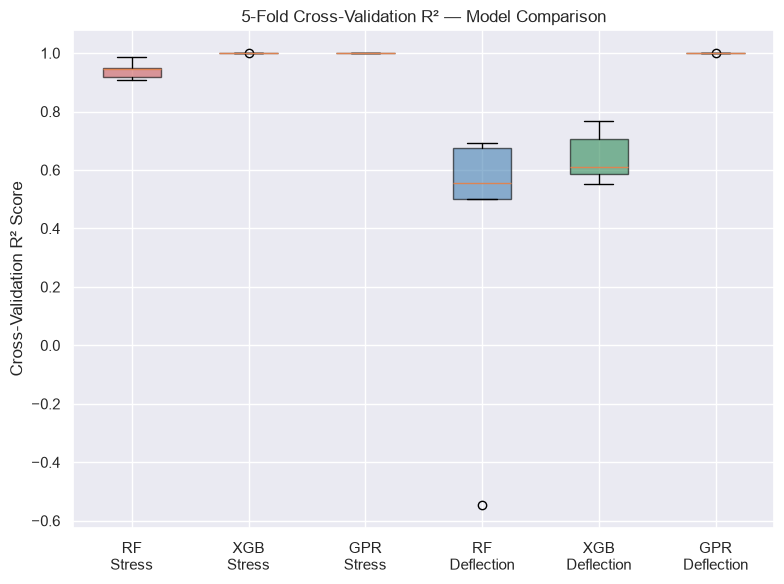

In [12]:
# Box plot comparison
labels = [
    "RF\nStress", "XGB\nStress", "GPR\nStress",
    "RF\nDeflection", "XGB\nDeflection", "GPR\nDeflection"
]
r2_data = [r2_rf_s, r2_xgb_s, r2_gpr_s, r2_rf_d, r2_xgb_d, r2_gpr_d]
colors = ["indianred", "darkorange", "firebrick", "steelblue", "seagreen", "royalblue"]

plot_cv_boxplot(
    r2_data, labels, colors,
    title="5-Fold Cross-Validation R² — Model Comparison"
)
plt.show()


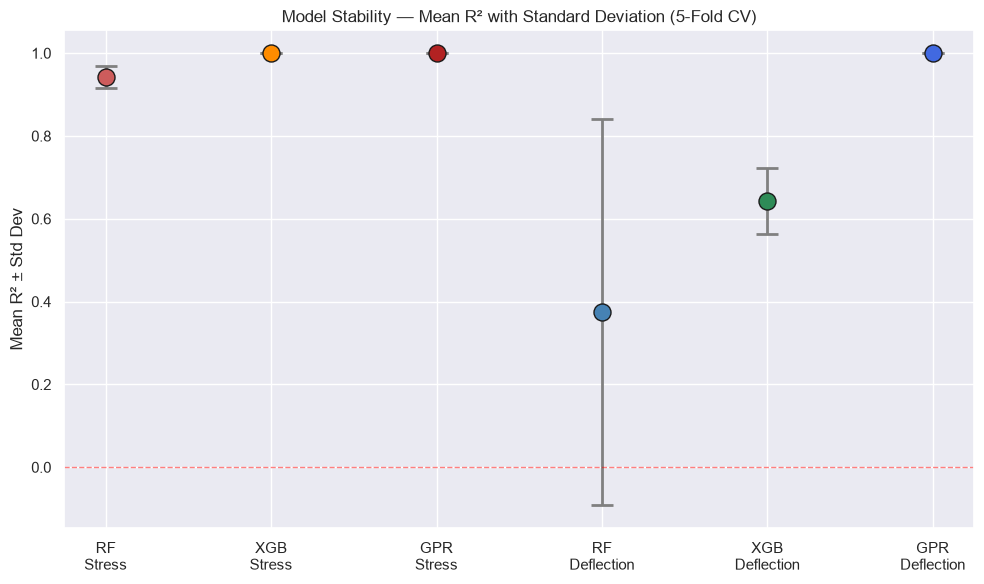

In [13]:
# Error bar plot comparison
means = [x.mean() for x in r2_data]
stds = [x.std() for x in r2_data]
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(labels))
for i, (m, c) in enumerate(zip(means, colors)):
    ax.scatter(x_pos[i], m, s=150, color=c, zorder=3, edgecolor="k")
ax.errorbar(x_pos, means, yerr=stds, fmt="none", capsize=8, capthick=2, elinewidth=2, ecolor="gray")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean R² ± Std Dev")
ax.set_title("Model Stability — Mean R² with Standard Deviation (5-Fold CV)")
ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()
